In [20]:
%matplotlib widget

In [21]:
import numpy as np
import pygimli as pg
import empymod as ep
import sys
import matplotlib.pyplot as plt
sys.path.insert(1, '../src')

from FDEM1D import FDEM1DModelling_nosort, LCModelling

from showStitched import showStitchedModels

from Plot import grid

In [22]:
print('Using files:')
print('data/data_3DChannel_nosort_new.npy')
print()

# model parameters [h_1, sigma_1, sigma_2]

data_true = np.load('data/data_3DChannel_nosort_new.npy')



Using files:
data/data_3DChannel_nosort_new.npy



In [23]:
# Load true model

model_true = np.load('models/model_3DChannel_new.npy')

In [24]:
# For each line (40 positions)
npos = 40

# Define a start model
model_ini = np.ones((npos, 3))
model_ini[:,0] = model_ini[:,0]*2   # initial thickness h_1
model_ini[:,1] = model_ini[:,1]*0.1 # initial sigma_1
model_ini[:,2] = model_ini[:,2]*0.1 # initial sigma_2

In [25]:
nLines = len(data_true)/npos
# number of lines nLines

In [26]:
# number of layers
nLayers = np.shape(model_ini)[1] -1

# number of measurement positions 
#npos = len(data_true)

model_inv_all = []
data_inv_all = []

for nL in range(int(nLines)):
    print('Inverting line:', nL)
    data_t = data_true[nL*npos : (nL+1)* npos].copy()
    
    LCI = LCModelling(FDEM1DModelling_nosort)
    
    LCI.initJacobian(dataVals=data_t, nLay=nLayers)
    LCI.createJacobian(model_ini)
    LCI.constraint_matrix(data_t, nLay=nLayers)
    LCI.normalization(data_t, cWeight_1=1, cWeight_2=1, nLay=nLayers)
    LCI.createWeight(data_t, cWeight_1=1, cWeight_2=1, nLay=nLayers)
    LCI.createConstraints()

    # Set transforms
    #transData = pg.trans.TransLog()
    transThk = pg.trans.TransLogLU(0.1,4)
    transSig = pg.trans.TransLogLU(5/1000,200/1000)
    
    LCI.region(1).setTransModel(transThk)
    LCI.region(2).setTransModel(transSig)
    
    # Create data vector
    data_true_vector = data_t.ravel()
    relativeError = np.ones_like(data_true_vector)*1e-3 

    # Run inversion
    inv = pg.Inversion(LCI)
    #inv.dataTrans = transData
    model_inv = inv.run(data_true_vector, relativeError, startModel=model_ini.ravel(), verbose=False, lam=1 )
    
    model_inv_all.append(np.array(model_inv).reshape(np.shape(model_ini)))
    data_inv = np.array(inv.response)
    data_inv_all.append(data_inv.reshape(np.shape(data_t)))

Inverting line: 0
Inversion is normalized
Jacobian size: 702 117 720


03/01/25 - 15:12:33 - Core - WARNING - no clear() implemented for:  18MatrixBase_wrapper
03/01/25 - 15:12:33 - Core - ERROR - no cWeights defined. You should create constraints matrix first.


cWeights are equal
Constraint cWeight length: 117
CW:  <pygimli.math.matrix.MultLeftMatrix object at 0x7efee41ada30>
Inverting line: 1
Inversion is normalized
Jacobian size: 702 117 720


03/01/25 - 15:12:36 - Core - WARNING - no clear() implemented for:  18MatrixBase_wrapper
03/01/25 - 15:12:36 - Core - ERROR - no cWeights defined. You should create constraints matrix first.


cWeights are equal
Constraint cWeight length: 117
CW:  <pygimli.math.matrix.MultLeftMatrix object at 0x7efee5b50860>
Inverting line: 2
Inversion is normalized
Jacobian size: 702 117 720


...

cWeights are equal
Constraint cWeight length: 117
CW:  <pygimli.math.matrix.MultLeftMatrix object at 0x7efee41375b0>
Inverting line: 38
Inversion is normalized
Jacobian size: 702 117 720


03/01/25 - 15:14:24 - Core - WARNING - no clear() implemented for:  18MatrixBase_wrapper
03/01/25 - 15:14:24 - Core - ERROR - no cWeights defined. You should create constraints matrix first.


cWeights are equal
Constraint cWeight length: 117
CW:  <pygimli.math.matrix.MultLeftMatrix object at 0x7efee5b50860>
Inverting line: 39
Inversion is normalized
Jacobian size: 702 117 720


03/01/25 - 15:14:27 - Core - WARNING - no clear() implemented for:  18MatrixBase_wrapper
03/01/25 - 15:14:27 - Core - ERROR - no cWeights defined. You should create constraints matrix first.


cWeights are equal
Constraint cWeight length: 117
CW:  <pygimli.math.matrix.MultLeftMatrix object at 0x7efeee082610>


In [27]:
m = np.array(model_inv_all)
data_inv_all = np.array(data_inv_all)

In [28]:
m.shape

(40, 40, 3)

In [29]:
model_true.shape

(40, 40, 3)

In [30]:
m[:,:,1:] = m[:,:,1:]*1000
model_true[:,:,1:] = model_true[:,:,1:]*1000

In [43]:
model_inv_grid = []

model_true_grid = []

for i in range(m.shape[0]):
    model_inv_grid.append(grid(m[i,:,:], depthmax=6))

for i in range(40):
    model_true_grid.append(grid(model_true[:,i,:], depthmax=6))

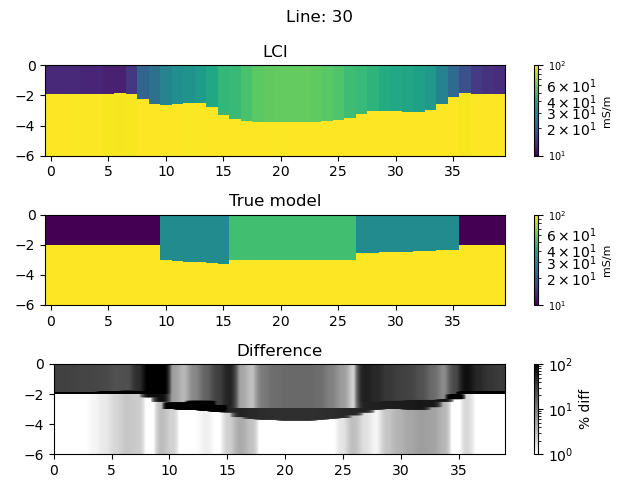

In [44]:
fig, ax = plt.subplots(3, )

l =30

showStitchedModels(m[l,:,:], zMax= 6, cMin=10, cMax=100, ax=ax[0], label='mS/m')
ax[0].set_title('LCI')
showStitchedModels(model_true[:,l,:], zMax= 6, cMin=10, cMax=100, ax=ax[1], label='mS/m')
ax[1].set_title('True model')

c2 = ax[2].imshow(np.abs((model_inv_grid[l].T - model_true_grid[l].T)/model_true_grid[l].T)*100, extent=([0, 39,-6,0]), cmap='binary', aspect=1.3, vmin=1, vmax=100, norm='log')
fig.colorbar(c2, ax=ax[2], label='% diff')
ax[2].set_title('Difference')

fig.suptitle('Line: '+str( l))

plt.tight_layout()

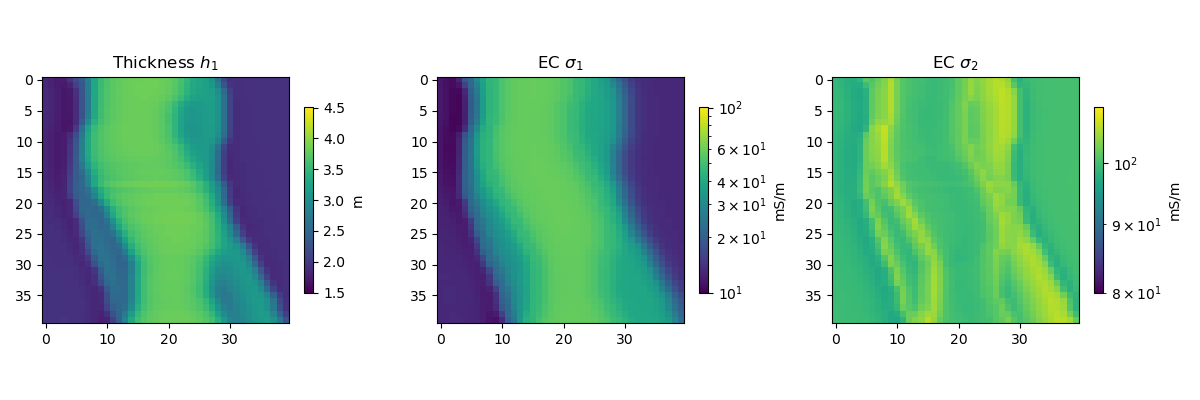

In [33]:


fig, ax = plt.subplots(1,3, figsize=(12,4))

c1 = ax[0].imshow(m[:,:,0], vmin=1.5, vmax=4.5)
fig.colorbar(c1, ax=ax[0], label='m', shrink=0.5)
ax[0].set_title('Thickness $h_1$')

c2 = ax[1].imshow(m[:,:,1], vmin =10, vmax=100, norm='log')
fig.colorbar(c2, ax=ax[1], label='mS/m', shrink=0.5)
ax[1].set_title('EC $\sigma_1$')

c3 = ax[2].imshow(m[:,:,2], vmin =80, vmax=110, norm='log')
fig.colorbar(c3, ax=ax[2], label='mS/m', shrink=0.5)
ax[2].set_title('EC $\sigma_2$')

plt.tight_layout()

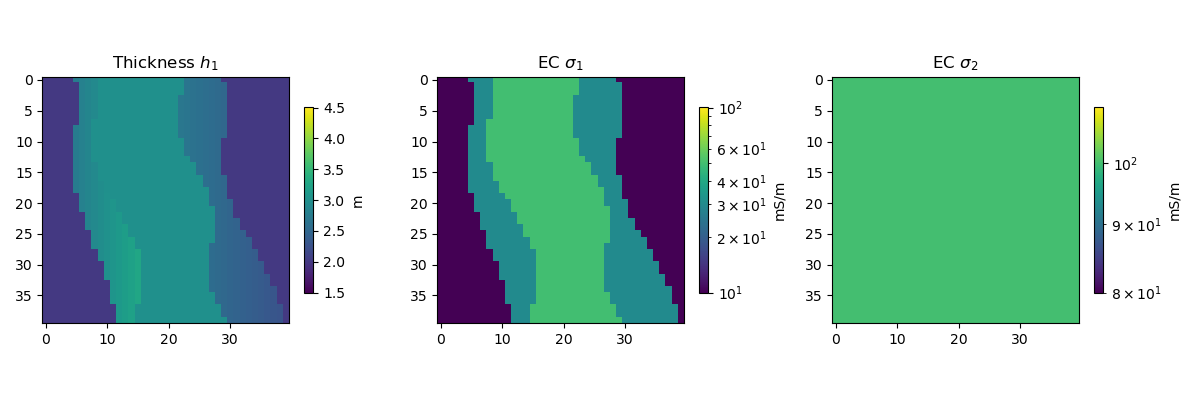

In [34]:
fig, ax = plt.subplots(1,3, figsize=(12,4))

c1 = ax[0].imshow(model_true[:,:,0].T, vmin=1.5, vmax=4.5)
fig.colorbar(c1, ax=ax[0], label='m', shrink=0.5)
ax[0].set_title('Thickness $h_1$')

c2 = ax[1].imshow(model_true[:,:,1].T, vmin =10, vmax=100, norm='log')
fig.colorbar(c2, ax=ax[1], label='mS/m', shrink=0.5)
ax[1].set_title('EC $\sigma_1$')

c3 = ax[2].imshow(model_true[:,:,2].T, vmin =80, vmax=110, norm='log')
fig.colorbar(c3, ax=ax[2], label='mS/m', shrink=0.5)
ax[2].set_title('EC $\sigma_2$')

plt.tight_layout()

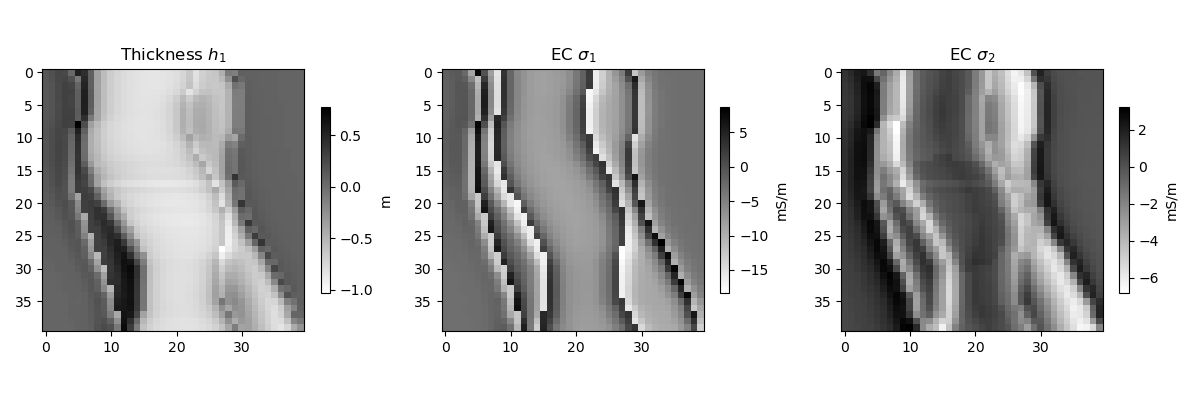

In [35]:
fig, ax = plt.subplots(1,3, figsize=(12,4))

c1 = ax[0].imshow(model_true[:,:,0].T-m[:,:,0], cmap='binary')
fig.colorbar(c1, ax=ax[0], label='m', shrink=0.5)
ax[0].set_title('Thickness $h_1$')

c2 = ax[1].imshow(model_true[:,:,1].T-m[:,:,1], cmap='binary')
fig.colorbar(c2, ax=ax[1], label='mS/m', shrink=0.5)
ax[1].set_title('EC $\sigma_1$')

c3 = ax[2].imshow(model_true[:,:,2].T-m[:,:,2], cmap='binary')
fig.colorbar(c3, ax=ax[2], label='mS/m', shrink=0.5)
ax[2].set_title('EC $\sigma_2$')

plt.tight_layout()

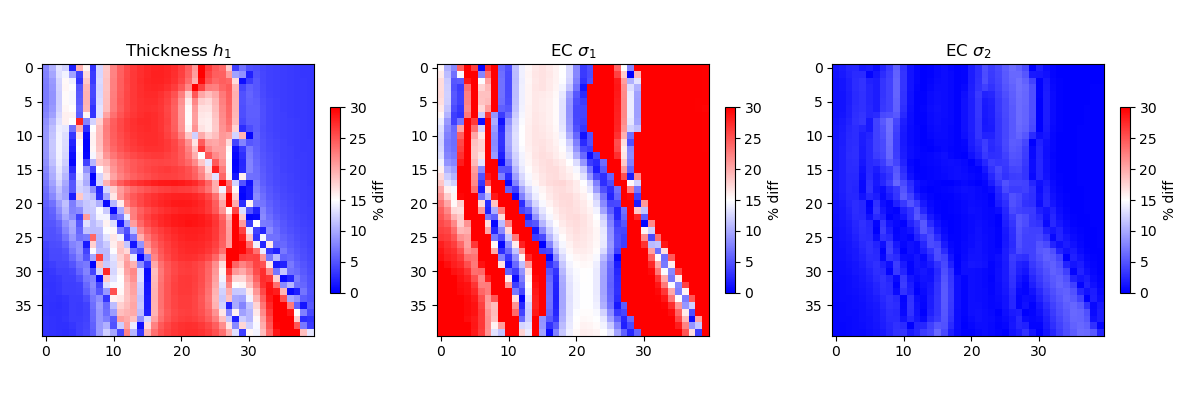

In [36]:
fig, ax = plt.subplots(1,3, figsize=(12,4))

c1 = ax[0].imshow(np.abs((model_true[:,:,0].T-m[:,:,0])/model_true[:,:,0].T)*100, cmap='bwr', vmin=0, vmax=30)
fig.colorbar(c1, ax=ax[0], label='% diff', shrink=0.5)
ax[0].set_title('Thickness $h_1$')

c2 = ax[1].imshow(np.abs((model_true[:,:,1].T-m[:,:,1])/model_true[:,:,1].T)*100, cmap='bwr', vmin=0, vmax=30)
fig.colorbar(c2, ax=ax[1], label='% diff', shrink=0.5)
ax[1].set_title('EC $\sigma_1$')

c3 = ax[2].imshow(np.abs((model_true[:,:,2].T-m[:,:,2])/model_true[:,:,2].T)*100, cmap='bwr', vmin=0, vmax=30)
fig.colorbar(c3, ax=ax[2], label='% diff', shrink=0.5)
ax[2].set_title('EC $\sigma_2$')

plt.tight_layout()

# Check data fit

In [37]:
# Data in PPT

d_true = (data_true.copy())*1000
d_inv = (data_inv_all)*1000

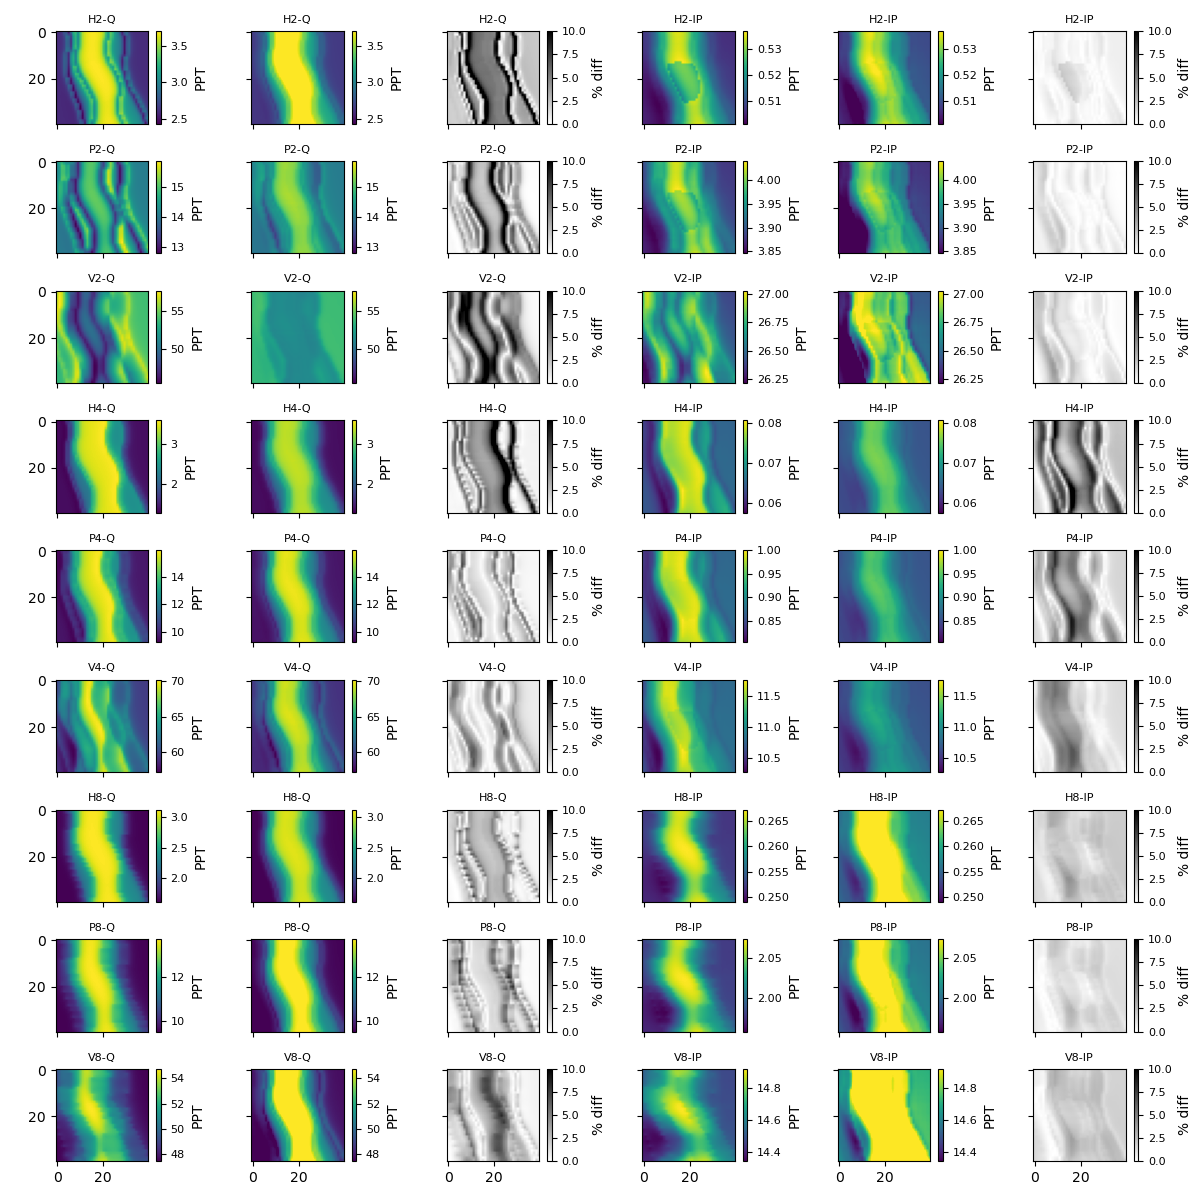

In [38]:
fig, ax = plt.subplots(9,6, figsize=(12,12), sharey=True, sharex=True)

configs = ['H2-Q', 'P2-Q', 'V2-Q', 'H4-Q', 'P4-Q', 'V4-Q', 'H8-Q', 'P8-Q', 'V8-Q', 
           'H2-IP', 'P2-IP', 'V2-IP', 'H4-IP', 'P4-IP', 'V4-IP', 'H8-IP', 'P8-IP', 'V8-IP', ]

fs=8

for i in range(9):
    vmin = min(d_true[:,i])
    vmax = max(d_true[:,i])
    
    c=ax[i,0].imshow(d_true[:,i].reshape(40,40), vmin=vmin, vmax=vmax)
    ax[i,0].set_title(configs[i], fontsize=fs)
    cb = fig.colorbar(c, ax=ax[i,0], label='PPT')
    cb.ax.tick_params(labelsize=fs)

    c=ax[i,1].imshow(d_inv[:,:,i], vmin=vmin, vmax=vmax)
    ax[i,1].set_title(configs[i], fontsize=fs)
    cb =fig.colorbar(c, ax=ax[i,1], label='PPT')
    cb.ax.tick_params(labelsize=fs)

    c=ax[i,2].imshow(np.abs((d_true[:,i].reshape(40,40) - d_inv[:,:,i])/d_true[:,i].reshape(40,40))*100, cmap='binary', vmin=0, vmax=10)
    ax[i,2].set_title(configs[i], fontsize=fs)
    cb=fig.colorbar(c, ax=ax[i,2], label='% diff')
    cb.ax.tick_params(labelsize=fs)

    vmin = min(d_true[:,i+9])
    vmax = max(d_true[:,i+9])
    
    c=ax[i,3].imshow(d_true[:,i+9].reshape(40,40), vmin=vmin, vmax=vmax)
    ax[i,3].set_title(configs[i+9], fontsize=fs)
    cb=fig.colorbar(c, ax=ax[i,3], label='PPT')
    cb.ax.tick_params(labelsize=fs)

    c=ax[i,4].imshow(d_inv[:,:,i+9], vmin=vmin, vmax=vmax)
    ax[i,4].set_title(configs[i+9], fontsize=fs)
    cb=fig.colorbar(c, ax=ax[i,4], label='PPT')
    cb.ax.tick_params(labelsize=fs)

    c=ax[i,5].imshow(np.abs((d_true[:,i+9].reshape(40,40) - d_inv[:,:,i+9])/d_true[:,i+9].reshape(40,40))*100, cmap='binary', vmin=0, vmax=10)
    ax[i,5].set_title(configs[i+9], fontsize=fs)
    cb=fig.colorbar(c, ax=ax[i,5], label='% diff')
    cb.ax.tick_params(labelsize=fs)


plt.tight_layout()

In [39]:
np.save('models/model_LCI_Channel', m)

In [45]:
np.save('models/model_LCI_Channel_grid', model_inv_grid)

In [46]:
np.save('models/model_true_grid', model_true_grid)